# Making our statiscal plots more appealing

## Two-sample problem
Let's recap our tutorial "*Statistical data analysis with Pandas and Pingouin (extended)*":

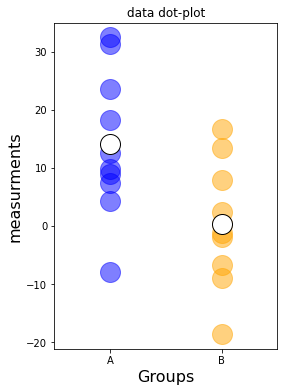

2021-12-17 10:33:21,415 [79408] WARNING  py.warnings:109: [JupyterRequire] /Users/husker/Science/Python/PyCharm Interpreters/Python Course/lib/python3.9/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.3.12, the latest is 0.5.0.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(



In [1]:
# Solution 2.1 from the Statistical data analysis tutorial:
import numpy as np
import matplotlib.pyplot as plt
import pingouin as pg

# Generate some random dummy data:
np.random.seed(1)
Group_A = np.random.randn(10)*10+15
Group_B = np.random.randn(10)*10+2

# we change the plots now:
fig=plt.figure(1, figsize=(4,6))
fig.clf()

# plt.bar([1, 2], [Group_A.mean(), Group_B.mean()])
xVals = np.ones(Group_A.shape[0])

plt.plot(xVals, Group_A, 'o', markeredgecolor="blue",
         markerfacecolor="blue", markersize=20,
         alpha=0.5)
plt.plot(1, Group_A.mean(), 'o', markeredgecolor="k",
         markerfacecolor="white", markersize=20)

plt.plot(xVals+1, Group_B, 'o', markeredgecolor="orange",
         markerfacecolor="orange", markersize=20,
         alpha=0.5)
plt.plot(2, Group_B.mean(), 'o', markeredgecolor="k",
         markerfacecolor="white", markersize=20)


plt.xticks([1,2], labels=["A", "B"])
plt.xlabel("Groups", fontsize=16)
plt.ylabel("measurments", fontsize=16)
plt.title("data dot-plot")

plt.xlim([0.5, 2.5])

plt.tight_layout
plt.show()
fig.savefig("barplot.pdf", dpi=120)

In [2]:
# check the statistics:
stats_results = pg.ttest(Group_A, Group_B, paired=False)
stats_results

,T,dof,tail,p-val,CI95%,cohen-d,BF10,power
T-test,2.648633,18,two-sided,0.016336,"[2.84, 24.61]",1.184505,3.649,0.707269


In [3]:
stats_results["p-val"]

T-test    0.016336
Name: p-val, dtype: float64

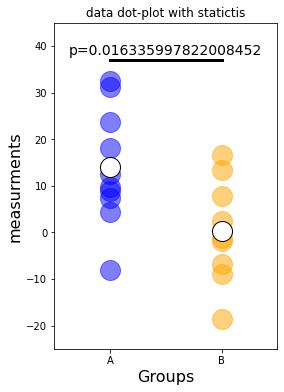

In [4]:
fig=plt.figure(1, figsize=(4,6))
fig.clf()

xVals = np.ones(Group_A.shape[0])

plt.plot(xVals, Group_A, 'o', markeredgecolor="blue",
         markerfacecolor="blue", markersize=20,
         alpha=0.5)
plt.plot(1, Group_A.mean(), 'o', markeredgecolor="k",
         markerfacecolor="white", markersize=20)

plt.plot(xVals+1, Group_B, 'o', markeredgecolor="orange",
         markerfacecolor="orange", markersize=20,
         alpha=0.5)
plt.plot(2, Group_B.mean(), 'o', markeredgecolor="k",
         markerfacecolor="white", markersize=20)

# statistical annotations:
h = 37  # "h" for l'haltitude (it's french)
annotation_offset = 0.5
plt.plot([1, 2], [h, h], '-k', lw=3)

"""
plt.text(1.5, h+annotation_offset, 
         "my p-vale="+str(5), 
         ha='center', va='bottom', fontsize=14)
"""
plt.text(1.5, h+annotation_offset, 
         "p="+str(stats_results["p-val"].values[0]), 
         ha='center', va='bottom', fontsize=14)

#plt.text(1.5, h+annotation_offset, stats_results["p-val"].values, 
#         fontsize=14)


plt.xticks([1,2], labels=["A", "B"])
plt.xlabel("Groups", fontsize=16)
plt.ylabel("measurments", fontsize=16)
plt.title("data dot-plot with statictis")

plt.xlim([0.5, 2.5])
plt.ylim([-25, 45])

plt.tight_layout
plt.show()
fig.savefig("dot plot with statictis.pdf", dpi=120)

## ad-hoc exercise
1. implement an if-statement to check for normality and let your script choose the right/corresponding significance test (ttest or Mann-Whitney-U). Hints: Pingoiun has a normality-check function as well as the corresponding test-functions.
1. Complete the decision tree for the stars annotation (p<.0001 ⟶ \*\*\*\*). You can use the notation convention from GraphPad ([link](https://www.graphpad.com/support/faq/what-is-the-meaning-of--or--or--in-reports-of-statistical-significance-from-prism-or-instat/)):
| Symbol | Meaning | 
|:---|:---|
|n.s. | p$>$0.05 |
|$*$ | p$\le$0.05 |
|$**$ | p$\le$0.01 |
|$***$ | p$\le$0.001 |
|$****$ | p$\le$0.0001 |
2. replace the p-value by the star annotation in the plot
4. round the displayed p-value and display it below the stars-annotation.

signficance tets applied: ttest


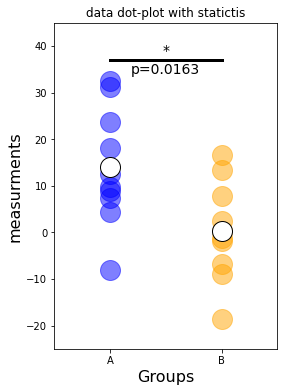

In [5]:
normtest_A = pg.normality(Group_A)
normtest_B = pg.normality(Group_B)

if (normtest_A['normal'].values) and (normtest_B['normal'].values): 
    stats_results = pg.ttest(Group_A, Group_B, paired=False)
    test_type="ttest"
else:
    stats_results = pg.mwu(Group_A, Group_B, alternative='two-sided')
    test_type="mwu"    
print(f"signficance tets applied: {test_type}")

fig=plt.figure(1, figsize=(4,6))
fig.clf()

xVals = np.ones(Group_A.shape[0])

plt.plot(xVals, Group_A, 'o', markeredgecolor="blue",
         markerfacecolor="blue", markersize=20,
         alpha=0.5)
plt.plot(1, Group_A.mean(), 'o', markeredgecolor="k",
         markerfacecolor="white", markersize=20)

plt.plot(xVals+1, Group_B, 'o', markeredgecolor="orange",
         markerfacecolor="orange", markersize=20,
         alpha=0.5)
plt.plot(2, Group_B.mean(), 'o', markeredgecolor="k",
         markerfacecolor="white", markersize=20)

# statistical annotations:
h = 37  # "h" for l'haltitude (it's french)
annotation_offset = 0.5
plt.plot([1, 2], [h, h], '-k', lw=3)

#stats_results["p-val"]=0.0013

if stats_results["p-val"].values<=0.0001:
    usetext="****"
    pval_string = "p<<=0.0001"
elif stats_results["p-val"].values<=0.001: 
    usetext="***"
    pval_string = "p="+str(stats_results["p-val"].values[0].round(4))
elif stats_results["p-val"].values<=0.01: 
    usetext="**"
    pval_string = "p="+str(stats_results["p-val"].values[0].round(4))
elif stats_results["p-val"].values<=0.05: 
    usetext="*"
    pval_string = "p="+str(stats_results["p-val"].values[0].round(4))
else: 
    usetext="n.s."

plt.text(1.5, h+annotation_offset, 
         usetext, 
         ha='center', va='bottom', fontsize=14)
#plt.text(1.5, h-annotation_offset, 
#         "p="+str(stats_results["p-val"].values[0].round(4)), 
#         ha='center', va='top', fontsize=14)
plt.text(1.5, h-annotation_offset, 
         pval_string, 
         ha='center', va='top', fontsize=14)



plt.xticks([1,2], labels=["A", "B"])
plt.xlabel("Groups", fontsize=16)
plt.ylabel("measurments", fontsize=16)
plt.title("data dot-plot with statictis")

plt.xlim([0.5, 2.5])
plt.ylim([-25, 45])

plt.tight_layout
plt.show()
fig.savefig("dot plot with statictis.pdf", dpi=120)

## *N*-samples problem
next week ^_^

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pingouin as pg
import pandas as pd

# Generate some random dummy data:
np.random.seed(1)
Group_A = np.random.randn(10,5)*10+15
Group_A[:,3] += 15 
Group_A.shape

(10, 5)

In [7]:
Group_A

array([[31.24345364,  8.88243586,  9.71828248, 19.27031378, 23.65407629],
       [-8.01538697, 32.44811764,  7.38793099, 33.19039096, 12.50629625],
       [29.62107937, -5.60140709, 11.77582796, 26.15945645, 26.33769442],
       [ 4.00108733, 13.27571792,  6.22141582, 30.42213747, 20.82815214],
       [ 3.99380823, 26.4472371 , 24.01590721, 35.02494339, 24.00855949],
       [ 8.16272141, 13.77109774,  5.64230566, 27.3211192 , 20.30355467],
       [ 8.08339248, 11.03246473,  8.128273  , 21.54794359,  8.28753869],
       [14.87335401,  3.82689651, 17.34415698, 46.59802177, 22.42044161],
       [13.08164448,  6.12371036,  7.52841706, 46.92454601, 15.50807755],
       [ 8.63004353, 16.90915485, 36.00255136, 31.20158952, 21.1720311 ]])

Let's recap our previous plot commands for the 2-sample-problem and make appropriate changes, in order to plot our 5-sample-problem:

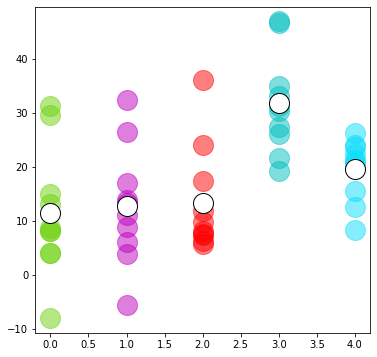

In [8]:
fig=plt.figure(1, figsize=(6,6))
fig.clf()

xVals = np.ones(Group_A.shape[0])

color =["#6DD20D", "m", "r", "c", "#0CDEFB"]
""" get color-hex-codes: https://htmlcolorcodes.com """

for col in range(Group_A.shape[1]):
    #plt.plot(xVals*col, Group_A[:,col], 'o',  markersize=16, 
    #         alpha=0.5)
    #plt.plot(xVals*col, Group_A[:,col], 'o', markeredgecolor="blue",
    #         markerfacecolor="blue", markersize=20,
    #         alpha=0.5)
    plt.plot(xVals*col, Group_A[:,col], 'o', 
             markeredgecolor=color[col],
             markerfacecolor=color[col], markersize=20,
             alpha=0.5)
    plt.plot(col, Group_A[:,col].mean(), 'o', markeredgecolor="k",
             markerfacecolor="white", markersize=20)

In [9]:
Group_A_df = pd.DataFrame(data=Group_A)
Group_A_df

,0,1,2,3,4
0,31.243454,8.882436,9.718282,19.270314,23.654076
1,-8.015387,32.448118,7.387931,33.190391,12.506296
2,29.621079,-5.601407,11.775828,26.159456,26.337694
3,4.001087,13.275718,6.221416,30.422137,20.828152
4,3.993808,26.447237,24.015907,35.024943,24.008559
5,8.162721,13.771098,5.642306,27.321119,20.303555
6,8.083392,11.032465,8.128273,21.547944,8.287539
7,14.873354,3.826897,17.344157,46.598022,22.420442
8,13.081644,6.123710,7.528417,46.924546,15.508078
9,8.630044,16.909155,36.002551,31.201590,21.172031


In [10]:
Group_A_df.describe()

,0,1,2,3,4
count,10.000000,10.000000,10.000000,10.000000,10.000000
mean,11.367520,12.711543,13.376507,31.766046,19.502642
std,11.815044,10.916066,9.806132,9.287301,5.663121
min,-8.015387,-5.601407,5.642306,19.270314,8.287539
25%,5.021664,6.813392,7.423053,26.449872,16.706947
50%,8.396382,12.154091,8.923278,30.811863,21.000092
75%,14.425427,16.124641,15.952075,34.566305,23.345668
max,31.243454,32.448118,36.002551,46.924546,26.337694


In [11]:
stats_anova = pg.rm_anova(data=Group_A_df)
stats_anova

,Source,ddof1,ddof2,F,p-unc,np2,eps
0,Within,4,36,7.018278,0.000277,0.438142,0.569053


In [12]:
Group_A_df_melt = Group_A_df.melt()
Group_A_df_melt

,variable,value
0,0,31.243454
1,0,-8.015387
2,0,29.621079
3,0,4.001087
4,0,3.993808
5,0,8.162721
6,0,8.083392
7,0,14.873354
8,0,13.081644
9,0,8.630044


* `variable`is our time (e.g., weeks (`between`))
* `value` is our measurment (i.e., dependent variable (`dv`))

In [13]:
id_array = np.array([np.arange(0,10)]*5).flatten()
id_array

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1,
       2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 3,
       4, 5, 6, 7, 8, 9])

In [14]:
Group_A_df_melt["Mice"] = id_array
Group_A_df_melt

,variable,value,Mice
0,0,31.243454,0
1,0,-8.015387,1
2,0,29.621079,2
3,0,4.001087,3
4,0,3.993808,4
5,0,8.162721,5
6,0,8.083392,6
7,0,14.873354,7
8,0,13.081644,8
9,0,8.630044,9


In [15]:
#stats_anova = pg.pairwise_ttests(data=Group_A_df.melt(),
#                                dv="value", between="variable")
#stats_anova

In [16]:
stats_anova = pg.pairwise_ttests(data=Group_A_df_melt, subject="Mice",
                                dv="value", within="variable",
                                padjust='holm')
stats_anova

,Contrast,A,B,Paired,Parametric,T,dof,Tail,p-unc,p-corr,p-adjust,BF10,hedges
0,variable,0,1,True,True,-0.196065,9.0,two-sided,0.848915,1.000000,holm,0.314,-0.113169
1,variable,0,2,True,True,-0.408473,9.0,two-sided,0.692474,1.000000,holm,0.332,-0.177220
2,variable,0,3,True,True,-3.822582,9.0,two-sided,0.004074,0.032590,holm,12.818,-1.838464
3,variable,0,4,True,True,-2.603032,9.0,two-sided,0.028596,0.171574,holm,2.705,-0.840983
4,variable,1,2,True,True,-0.157430,9.0,two-sided,0.878381,1.000000,holm,0.312,-0.061379
5,variable,1,3,True,True,-4.206639,9.0,two-sided,0.002284,0.020557,holm,20.603,-1.800726
6,variable,1,4,True,True,-1.544520,9.0,two-sided,0.156861,0.627442,holm,0.768,-0.747971
7,variable,2,3,True,True,-4.713424,9.0,two-sided,0.001099,0.010992,holm,37.765,-1.844196
8,variable,2,4,True,True,-2.061377,9.0,two-sided,0.069325,0.346627,holm,1.38,-0.732749
9,variable,3,4,True,True,3.583875,9.0,two-sided,0.005895,0.041265,holm,9.49,1.526998


In [17]:
print(stats_anova.iloc[9]["A"], stats_anova.iloc[9]["B"],
      stats_anova.iloc[9]["p-corr"])

3 4 0.04126457187017616


In [18]:
df_test = pg.read_dataset('mixed_anova.csv')
df_test

,Scores,Time,Group,Subject
0,5.971435,August,Control,0
1,4.309024,August,Control,1
2,6.932707,August,Control,2
3,5.187348,August,Control,3
4,4.779411,August,Control,4
...,...,...,...,...
175,6.176981,June,Meditation,55
176,8.523692,June,Meditation,56
177,6.522273,June,Meditation,57
178,4.990568,June,Meditation,58


In [19]:
pg.pairwise_ttests(dv='Scores', between='Group', 
                   data=df_test).round(3)

,Contrast,A,B,Paired,Parametric,T,dof,Tail,p-unc,BF10,hedges
0,Group,Control,Meditation,False,True,-2.29,178.0,two-sided,0.023,1.813,-0.34


In [20]:
post_hocs = pg.pairwise_ttests(dv='Scores', within='Time', 
                               subject='Subject', between='Group', 
                               padjust='holm', data=df_test)
post_hocs

,Contrast,Time,A,B,Paired,Parametric,T,dof,Tail,p-unc,p-corr,p-adjust,BF10,hedges
0,Time,-,August,January,True,True,-1.740370,59.0,two-sided,0.087008,0.174015,holm,0.582,-0.327583
1,Time,-,August,June,True,True,-2.743238,59.0,two-sided,0.008045,0.024134,holm,4.232,-0.482547
2,Time,-,January,June,True,True,-1.023620,59.0,two-sided,0.310194,0.310194,holm,0.232,-0.169520
3,Group,-,Control,Meditation,False,True,-2.247601,58.0,two-sided,0.028420,NaN,NaN,2.096,-0.572791
4,Time * Group,August,Control,Meditation,False,True,0.316022,58.0,two-sided,0.753120,0.753120,holm,0.274,0.080537
5,Time * Group,January,Control,Meditation,False,True,-1.433725,58.0,two-sided,0.157020,0.314040,holm,0.619,-0.365379
6,Time * Group,June,Control,Meditation,False,True,-2.744291,58.0,two-sided,0.008058,0.024173,holm,5.593,-0.699371


In [21]:
post_hocs = pg.pairwise_ttests(dv='Scores', within='Time', 
                               subject='Subject', 
                               padjust='bonf', data=df_test)
post_hocs

,Contrast,A,B,Paired,Parametric,T,dof,Tail,p-unc,p-corr,p-adjust,BF10,hedges
0,Time,August,January,True,True,-1.740370,59.0,two-sided,0.087008,0.261023,bonf,0.582,-0.327583
1,Time,August,June,True,True,-2.743238,59.0,two-sided,0.008045,0.024134,bonf,4.232,-0.482547
2,Time,January,June,True,True,-1.023620,59.0,two-sided,0.310194,0.930581,bonf,0.232,-0.169520
